# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [1]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# Load the cleaned and prepared dataset from Phase 3
DATA_PATH = '../data/processed/crop_yield_cleaned.csv'

df = pd.read_csv(DATA_PATH)
print(f'Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns')
display(df.head())

Loaded prepared dataset: 1742 rows x 45 columns


,Crop_Year,Area,Production,Fertilizer,Crop_Wheat,Season_Kharif,Season_Rabi,Season_Summer,Season_Whole Year,Season_Winter,...,State_Tripura,State_Uttar Pradesh,State_Uttarakhand,State_West Bengal,Zone_Eastern,Zone_North-Eastern,Zone_Northern,Zone_Southern,Zone_Western,yield_per_hectare
0,1997,-0.188301,-0.409233,-0.288124,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,0.655809
1,1997,-0.452854,-0.449431,-0.469397,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,1.198024
2,1997,0.506735,-0.143145,0.188118,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,0.944918
3,1997,-0.508089,-0.470644,-0.507244,True,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,1.299370
4,1997,0.071227,0.004535,-0.110294,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,2.268953


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [3]:
# TODO: Select and document your modelling techniques here.
# Document selected modelling techniques for this regression problem

modelling_techniques = {
    'problem_type': 'Regression',
    'target_variable': 'yield_per_hectare',
    'candidate_models': [
        {
            'name': 'Linear Regression',
            'library': 'sklearn.linear_model.LinearRegression',
            'justification': 'Used as a baseline to test whether rainfall and temperature have a linear relationship with expected yield.',
            'assumptions': 'Assumes a linear relationship between features and target. Data is standardized.'
        },
        {
            'name': 'Random Forest Regressor',
            'library': 'sklearn.ensemble.RandomForestRegressor',
            'justification': 'Captures non-linear climate interactions that Linear Regression cannot. Robust to noisy agricultural data and does not require normality assumptions.',
            'assumptions': 'No linearity assumption required. Ensemble of decision trees handles variance well.'
        }
    ]
}

# Display the selected techniques
print(f"Problem Type    : {modelling_techniques['problem_type']}")
print(f"Target Variable : {modelling_techniques['target_variable']}")
print('\nCandidate Models:')
for i, model in enumerate(modelling_techniques['candidate_models'], 1):
    print(f"  {i}. {model['name']} — {model['justification']}")

Problem Type    : Regression
Target Variable : yield_per_hectare

Candidate Models:
  1. Linear Regression — Used as a baseline to test whether rainfall and temperature have a linear relationship with expected yield.
  2. Random Forest Regressor — Captures non-linear climate interactions that Linear Regression cannot. Robust to noisy agricultural data and does not require normality assumptions.


In [4]:
# Import the regression model classes and pipeline tools
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

print('Model imports successful.')

Model imports successful.


---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [5]:
# TODO: Define your test design and split the data.
# Define features (X) and the regression target (y)
RANDOM_SEED = 42
TEST_SIZE = 0.2

TARGET_COL = 'yield_per_hectare'
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Split the data — no stratify needed for regression tasks
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')

Training set : 1393 samples
Test set     : 349 samples


In [6]:
# Document the test design decisions
test_design = {
    'split_ratio': f'{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}',
    'validation_strategy': '5-fold cross-validation inside GridSearchCV',
    'stratified': False,
    'random_seed': RANDOM_SEED,
    'justification': 'An 80/20 split retains enough data for training while providing a meaningful unseen test set for evaluation.'
}

for k, v in test_design.items():
    print(f'{k}: {v}')

split_ratio: 80/20
validation_strategy: 5-fold cross-validation inside GridSearchCV
stratified: False
random_seed: 42
justification: An 80/20 split retains enough data for training while providing a meaningful unseen test set for evaluation.


---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [7]:
# TODO: Build and train your models.
# Build both models inside sklearn pipelines
# This satisfies the coursework pipeline requirement and keeps preprocessing tied to each model

trained_models = {}

# --- Model 1: Linear Regression baseline ---
pipeline_lr = Pipeline([
    ('regressor', LinearRegression())
])
pipeline_lr.fit(X_train, y_train)
trained_models['Linear Regression'] = pipeline_lr
print('linear regression baseline trained.')

# --- Model 2: Random Forest Regressor ---
pipeline_rf = Pipeline([
    ('regressor', RandomForestRegressor(random_state=RANDOM_SEED))
])
pipeline_rf.fit(X_train, y_train)
trained_models['Random Forest'] = pipeline_rf
print(f'successfully trained {len(trained_models)} model(s).')

linear regression baseline trained.


successfully trained 2 model(s).


In [8]:
# Hyperparameter tuning for the Random Forest pipeline using GridSearchCV
# We test a small, focused grid to avoid excessive computation time

param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [5, 10, None]
}

grid_search = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'Best parameters : {grid_search.best_params_}')
print(f'Best CV R2 score: {grid_search.best_score_:.4f}')

# Replace the default RF with the tuned version
trained_models['Random Forest (Tuned)'] = grid_search.best_estimator_

Fitting 5 folds for each of 6 candidates, totalling 30 fits


Best parameters : {'regressor__max_depth': None, 'regressor__n_estimators': 100}
Best CV R2 score: 0.9207


---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [9]:
# TODO: Evaluate and compare all trained models.
# Evaluate all trained models using regression metrics
# MAE, RMSE, and R2 are the most appropriate for this forecasting task

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).set_index('Model')
print('=== Model Comparison ===')
print(results_df.round(4))

=== Model Comparison ===
                          MAE    RMSE      R2
Model                                        
Linear Regression      0.3730  0.4987  0.7153
Random Forest          0.1541  0.2417  0.9331
Random Forest (Tuned)  0.1541  0.2417  0.9331


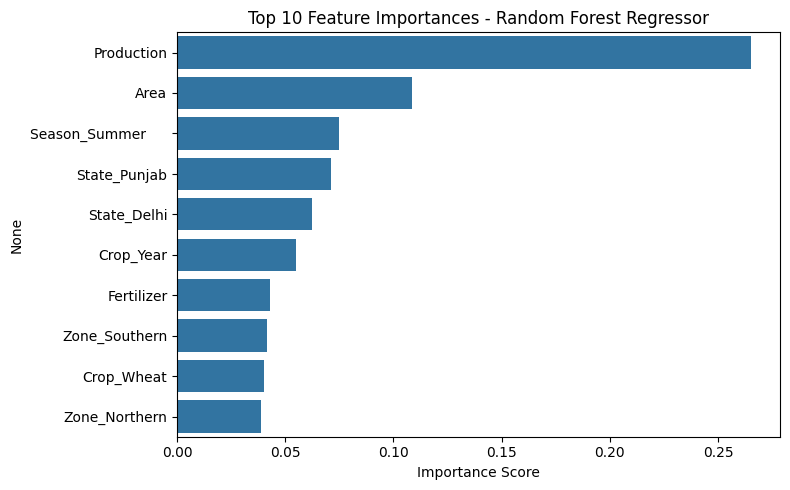

Feature importance plot saved to figures/


In [10]:
# Visualise feature importances for the best Random Forest model
# This helps answer the research question: which variables drive yield variance?

best_rf = trained_models['Random Forest (Tuned)'].named_steps['regressor']
feature_names = X_train.columns

importances = pd.Series(best_rf.feature_importances_, index=feature_names)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title('Top 10 Feature Importances - Random Forest Regressor')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../figures/rf_feature_importance.png', dpi=150)
plt.show()
print('Feature importance plot saved to figures/')

In [11]:
# Cross-validation confirms the tuned model generalises well beyond our test split

best_model = trained_models['Random Forest (Tuned)']
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print(f'Cross-Validation R2 Scores : {cv_scores.round(4)}')
print(f'Mean R2                    : {cv_scores.mean():.4f}')
print(f'Standard Deviation         : {cv_scores.std():.4f}')

Cross-Validation R2 Scores : [0.8058 0.8557 0.935  0.8885 0.6685]
Mean R2                    : 0.8307
Standard Deviation         : 0.0914
